In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    '../data/logins.csv',
    parse_dates=['timestamp_login']
)

#Lendo as principais informações dos dados
print(df.head())
print(df.shape)
print(df.dtypes)
df.info()

print(df.describe())
colunas_numericas = [
    'tentativas_falhas',
    'distancia_km',
    'tempo_desde_ultimo_login'
]

print(
    df[colunas_numericas].describe()
)

      timestamp_login  tentativas_falhas  novo_dispositivo  novo_ip  \
0 2026-01-01 00:15:17                  1                 0        0   
1 2026-01-01 01:08:58                  0                 0        0   
2 2026-01-01 01:47:44                  0                 0        0   
3 2026-01-01 05:27:55                  0                 1        0   
4 2026-01-01 06:00:50                  1                 0        1   

   vpn_proxy  pais_diferente  distancia_km  usuario_id  \
0          0               0        163.60         250   
1          0               0         57.78         246   
2          0               0        234.49          99   
3          0               0         85.56         120   
4          0               0        170.30          26   

   tempo_desde_ultimo_login  primeiro_login  login_suspeito  
0                   8934.41               1               0  
1                   8934.41               1               0  
2                   8934.41           

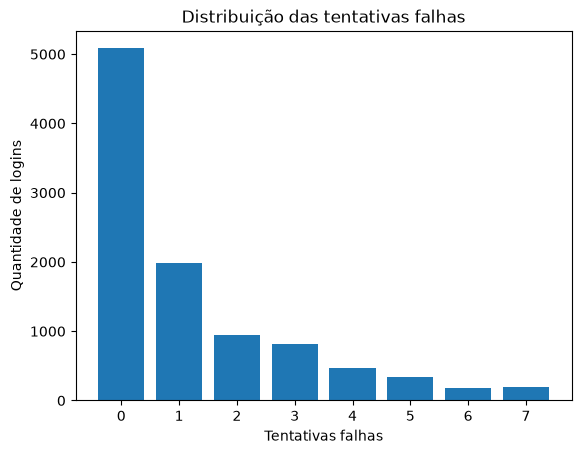

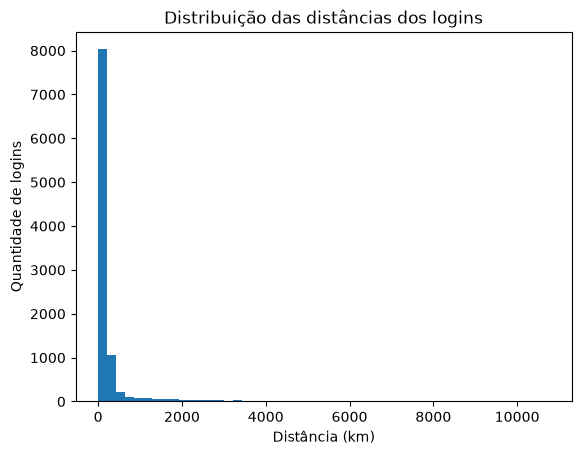

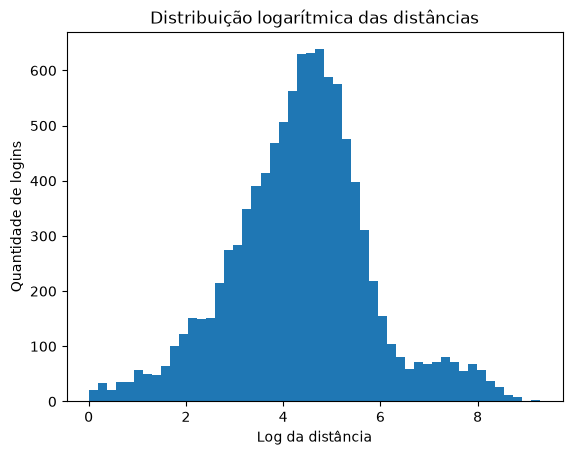

login_suspeito
0    92.8
1     7.2
Name: proportion, dtype: float64


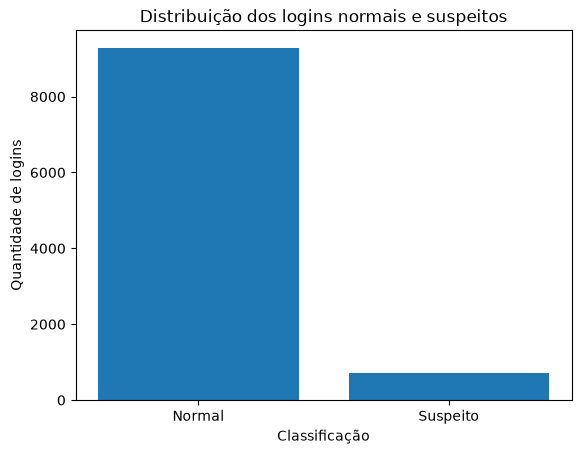

In [8]:
#Fazendo gráficos para entender melhor seus parametros
contagem_falhas = (df['tentativas_falhas'].value_counts().sort_index())
plt.bar(contagem_falhas.index, contagem_falhas.values)
plt.xlabel('Tentativas falhas')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição das tentativas falhas')
plt.show()

plt.hist(df['distancia_km'], bins=50)
plt.xlabel('Distância (km)')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição das distâncias dos logins')
plt.show()

df['distancia_log'] = np.log1p(df['distancia_km'])
plt.hist(df['distancia_log'], bins=50)
plt.xlabel('Log da distância')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição logarítmica das distâncias')
plt.show()

contagem_target = (df['login_suspeito'].value_counts().sort_index())
plt.bar(contagem_target.index, contagem_target.values)
plt.xticks([0, 1], ['Normal', 'Suspeito'])
plt.xlabel('Classificação')
plt.ylabel('Quantidade de logins')
plt.title('Distribuição dos logins normais e suspeitos')
print(df['login_suspeito'].value_counts(normalize=True)* 100)


tentativas_falhas
0     5.293192
1     6.268959
2     7.936508
3    11.344020
4    11.677282
5    13.313609
6    14.364641
7    17.525773
Name: login_suspeito, dtype: float64


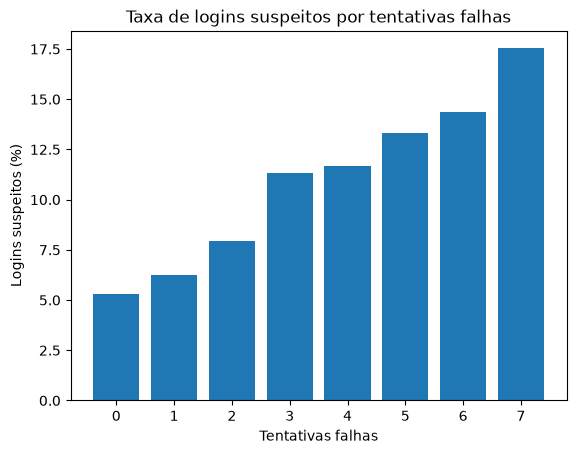

In [9]:
#Tirando conclusões do peso de parametros para um login suspeito
df.groupby('login_suspeito')['tentativas_falhas'].mean()
df.groupby('login_suspeito')['tentativas_falhas'].median()
df.groupby('login_suspeito')['tentativas_falhas'].describe()

taxa_suspeitos_por_falhas = (
    df.groupby('tentativas_falhas')['login_suspeito']
    .mean()
    * 100
)
print(taxa_suspeitos_por_falhas)
plt.bar(taxa_suspeitos_por_falhas.index, taxa_suspeitos_por_falhas.values)
plt.xlabel('Tentativas falhas')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por tentativas falhas')
plt.show()

novo_dispositivo
0     6.395349
1    14.015152
Name: login_suspeito, dtype: float64


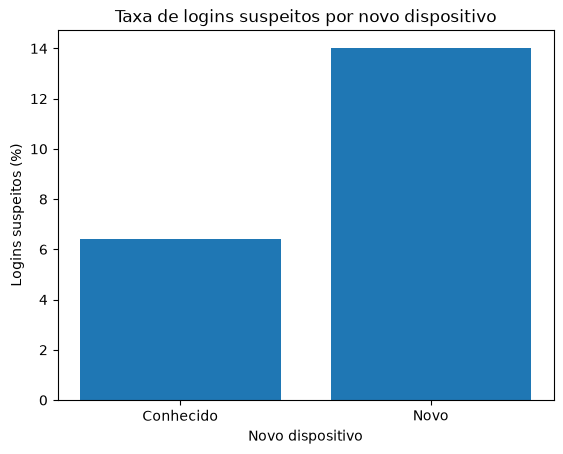

In [10]:
taxa_suspeitos_dispositivo = (df.groupby('novo_dispositivo')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_dispositivo)
plt.bar(taxa_suspeitos_dispositivo.index, taxa_suspeitos_dispositivo.values)
plt.xticks([0, 1], ['Conhecido', 'Novo'])
plt.xlabel('Novo dispositivo')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por novo dispositivo')
plt.show()

novo_ip
0     4.695652
1    12.774194
Name: login_suspeito, dtype: float64


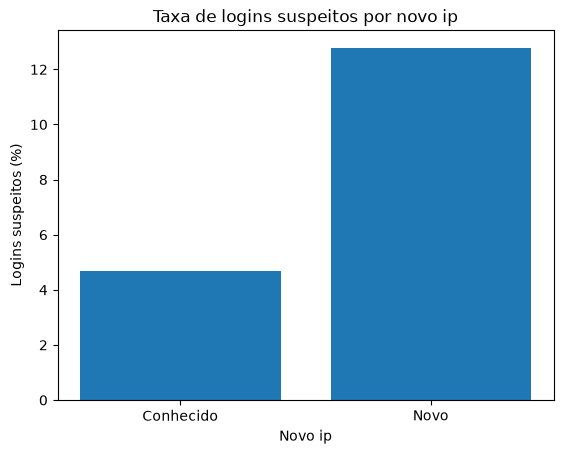

In [11]:
taxa_suspeitos_ip = (df.groupby('novo_ip')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_ip)
plt.bar(taxa_suspeitos_ip.index, taxa_suspeitos_ip.values)
plt.xticks([0, 1], ['Conhecido', 'Novo'])
plt.xlabel('Novo ip')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por novo ip')
plt.show()

vpn_proxy
0     6.251494
1    12.056304
Name: login_suspeito, dtype: float64


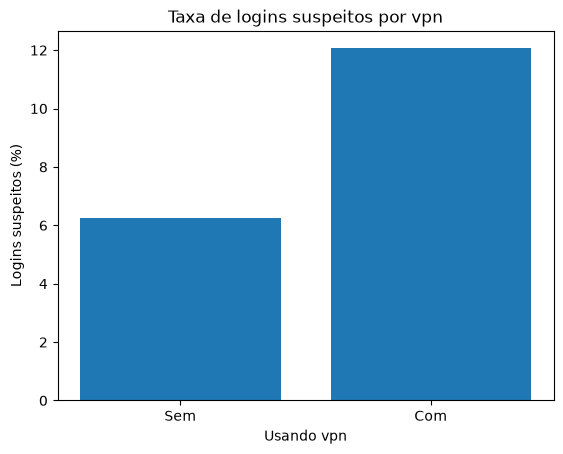

In [12]:
taxa_suspeitos_vpn = (df.groupby('vpn_proxy')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_vpn)
plt.bar(taxa_suspeitos_vpn.index, taxa_suspeitos_vpn.values)
plt.xticks([0, 1], ['Sem', 'Com'])
plt.xlabel('Usando vpn')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por vpn')
plt.show()

pais_diferente
0     5.738897
1    19.509896
Name: login_suspeito, dtype: float64


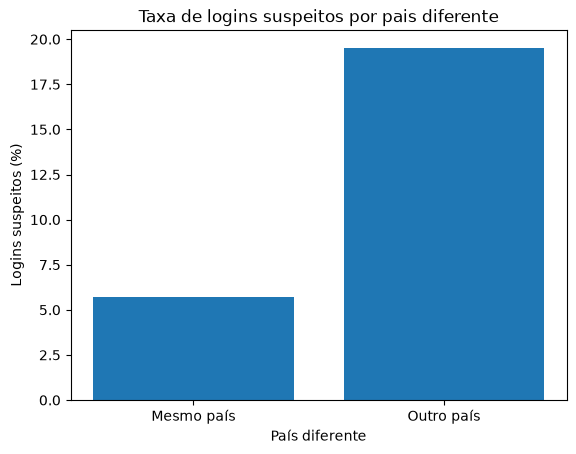

In [13]:
taxa_suspeitos_pais = (df.groupby('pais_diferente')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_pais)
plt.bar(taxa_suspeitos_pais.index, taxa_suspeitos_pais.values)
plt.xticks([0, 1], ['Mesmo país', 'Outro país'])
plt.xlabel('País diferente')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por pais diferente')
plt.show()

                 count      mean       std       min       25%       50%  \
login_suspeito                                                             
0               9280.0  4.324349  1.408775  0.009950  3.489742  4.397654   
1                720.0  4.952905  1.741293  0.223144  3.816613  4.907605   

                     75%      max  
login_suspeito                     
0               5.132514  9.26166  
1               5.966666  9.28391  


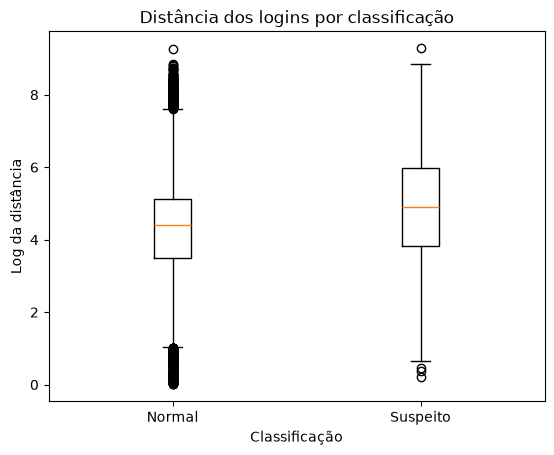

In [14]:
print(df.groupby('login_suspeito')['distancia_log'].describe())
plt.boxplot(
    [
        df[df['login_suspeito'] == 0]['distancia_log'],
        df[df['login_suspeito'] == 1]['distancia_log']
    ],
    tick_labels=['Normal', 'Suspeito']
)

plt.xlabel('Classificação')
plt.ylabel('Log da distância')
plt.title('Distância dos logins por classificação')
plt.show()

hora_login
0      8.254717
1      7.711443
2      9.442060
3      8.620690
4     12.356979
5     10.046729
6      5.133929
7      7.948718
8      7.211538
9      5.811138
10     6.060606
11     9.350649
12     6.619385
13     6.493506
14     6.683168
15     7.434053
16     9.090909
17     7.075472
18     4.207921
19     5.990783
20     3.738318
21     4.050633
22     6.617647
23     6.323185
Name: login_suspeito, dtype: float64


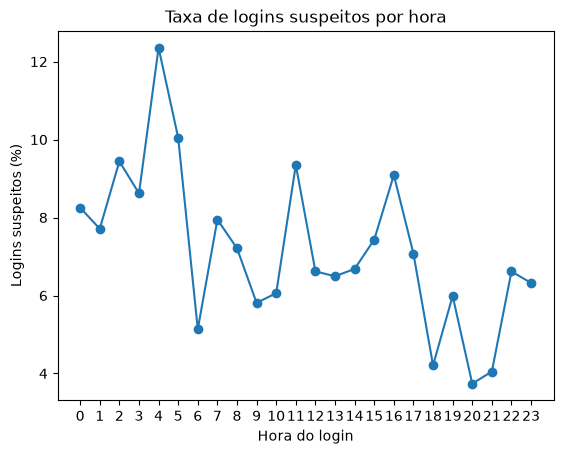

login_madrugada
0    6.427323
1    9.442060
Name: login_suspeito, dtype: float64
                          tentativas_falhas  novo_dispositivo   novo_ip  \
tentativas_falhas                  1.000000         -0.006378  0.000264   
novo_dispositivo                  -0.006378          1.000000  0.310717   
novo_ip                            0.000264          0.310717  1.000000   
vpn_proxy                         -0.012347          0.089283  0.265185   
pais_diferente                    -0.016161          0.114066  0.374277   
distancia_km                      -0.021013          0.087944  0.263708   
usuario_id                         0.000303          0.001991 -0.003999   
tempo_desde_ultimo_login          -0.010774          0.014109  0.011170   
primeiro_login                     0.007048         -0.013339 -0.002077   
login_suspeito                     0.112340          0.090594  0.144543   
distancia_log                     -0.017977          0.076104  0.217766   
tempo_log          

In [15]:
df.groupby('login_suspeito')['tempo_desde_ultimo_login'].describe()
df['tempo_log'] = np.log1p(
    df['tempo_desde_ultimo_login']
)
df.groupby('login_suspeito')['tempo_log'].describe()

df['hora_login'] = df['timestamp_login'].dt.hour
taxa_suspeitos_hora = (df.groupby('hora_login')['login_suspeito'].mean()* 100)
print(taxa_suspeitos_hora)

plt.plot(
    taxa_suspeitos_hora.index,
    taxa_suspeitos_hora.values,
    marker='o'
)
plt.xlabel('Hora do login')
plt.ylabel('Logins suspeitos (%)')
plt.title('Taxa de logins suspeitos por hora')
plt.xticks(range(24))
plt.show()

df['login_madrugada'] = (
    (df['hora_login'] >= 0) &
    (df['hora_login'] <= 5)
).astype(int)
taxa_madrugada = (
    df.groupby('login_madrugada')['login_suspeito']
    .mean()
    * 100
)
print(taxa_madrugada)

correlacao = df.corr(numeric_only=True)
print(correlacao)
print(
    correlacao['login_suspeito']
    .sort_values(ascending=False)
)

correlacao_target = (
    correlacao['login_suspeito']
    .sort_values(ascending=False)
)
print(correlacao_target.to_string())

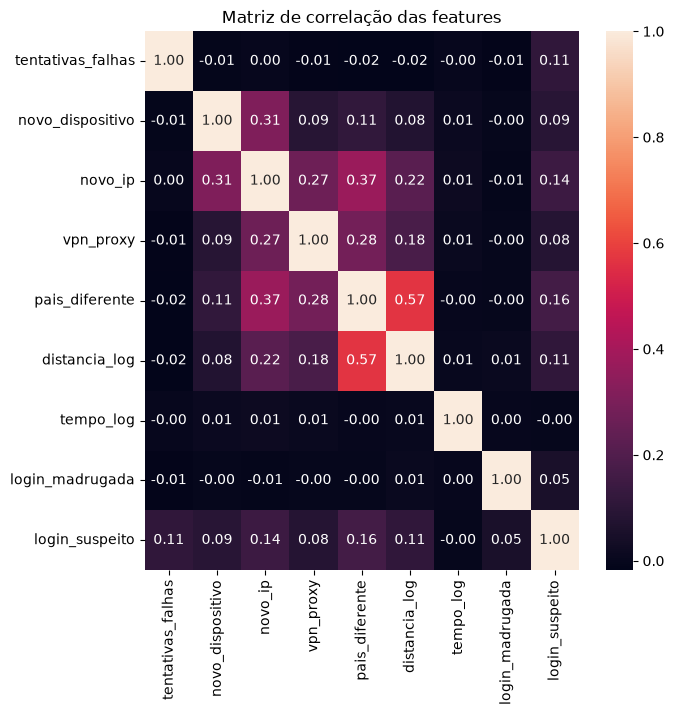

In [16]:
import seaborn as sns
colunas_correlacao = [
    'tentativas_falhas',
    'novo_dispositivo',
    'novo_ip',
    'vpn_proxy',
    'pais_diferente',
    'distancia_log',
    'tempo_log',
    'login_madrugada',
    'login_suspeito'
]
matriz_correlacao = df[colunas_correlacao].corr()
plt.figure(figsize=(7, 7))
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f')
plt.title('Matriz de correlação das features')
plt.show()

In [17]:
features = [
'tentativas_falhas',
'novo_dispositivo',
'novo_ip',
'vpn_proxy',
'pais_diferente',
'distancia_log',
'tempo_log',
'primeiro_login',
'login_madrugada'
]

x = df[features]
y = df['login_suspeito']

print(x.head())
print(x.shape)

print(y.head())
print(y.shape)

   tentativas_falhas  novo_dispositivo  novo_ip  vpn_proxy  pais_diferente  \
0                  1                 0        0          0               0   
1                  0                 0        0          0               0   
2                  0                 0        0          0               0   
3                  0                 1        0          0               0   
4                  1                 0        1          0               0   

   distancia_log  tempo_log  primeiro_login  login_madrugada  
0       5.103518   9.097777               1                1  
1       4.073802   9.097777               1                1  
2       5.461668   9.097777               1                1  
3       4.460838   9.097777               1                1  
4       5.143416   9.097777               1                0  
(10000, 9)
0    0
1    0
2    0
3    0
4    0
Name: login_suspeito, dtype: int64
(10000,)


In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

print(x_train.shape)
print(x_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(7000, 9)
(3000, 9)
login_suspeito
0    0.928
1    0.072
Name: proportion, dtype: float64
login_suspeito
0    0.928
1    0.072
Name: proportion, dtype: float64


In [ ]:
#Preparando o modelo pela primeira vez
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=42))
])
print(modelo_lr)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, random_state=42))])


In [ ]:
#Pipeline treinado com atributos ajustados
modelo_lr.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['tentativas_falhas','novo_dispositivo','novo_ip',...,'tempo_log', 'primeiro_login','login_madrugada']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
y_pred = modelo_lr.predict(x_test)
print(y_pred[:20])
print(len(y_pred))

print(pd.Series(y_pred).value_counts())
print(pd.Series(y_pred).value_counts(normalize=True) * 100)
#O modelo classificou os 3 mil logins como normais devido ao desbalanceamento

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
3000
0    3000
Name: count, dtype: int64
0    100.0
Name: proportion, dtype: float64


In [28]:
from sklearn.metrics import confusion_matrix

matriz_confusao = confusion_matrix(y_test, y_pred)
print(matriz_confusao) #Provando que ele classificou todos os normais(0) e suspeitos(1) como normal(0)

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

probabilidades = modelo_lr.predict_proba(X_test)
print(probabilidades[:5])
print(probabilidades.shape)
prob_suspeito = probabilidades[:, 1]
print(prob_suspeito[:20])
print('Mínima:', prob_suspeito.min())
print('Máxima:', prob_suspeito.max())
print('Média:', prob_suspeito.mean())


[[2784    0]
 [ 216    0]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      2784
           1       0.00      0.00      0.00       216

    accuracy                           0.93      3000
   macro avg       0.46      0.50      0.48      3000
weighted avg       0.86      0.93      0.89      3000

[[0.88568767 0.11431233]
 [0.94876821 0.05123179]
 [0.97239253 0.02760747]
 [0.97475214 0.02524786]
 [0.96723023 0.03276977]]
(3000, 2)
[0.11431233 0.05123179 0.02760747 0.02524786 0.03276977 0.0961874
 0.03024847 0.3450101  0.03351562 0.0285715  0.06370283 0.02951878
 0.2012126  0.08309585 0.04507983 0.16083761 0.0550815  0.04516162
 0.04133912 0.05239422]
Mínima: 0.023347110872262856
Máxima: 0.4980350800427855
Média: 0.07093378465502449


In [ ]:
from sklearn.metrics import roc_auc_score

#Entender se o modelo consegue classificar os suspeitos reais mais suspeitos que os normais
roc_auc = roc_auc_score(
    y_test,
    prob_suspeito
)
print('ROC-AUC:', roc_auc)

from sklearn.metrics import average_precision_score

#Average precision pega a curva media de precision-recall de vários thresholds  
average_precision = average_precision_score(
    y_test,
    prob_suspeito
)
print('Average Precision:', average_precision)

ROC-AUC: 0.7535886281396339
Average Precision: 0.2051779290376525


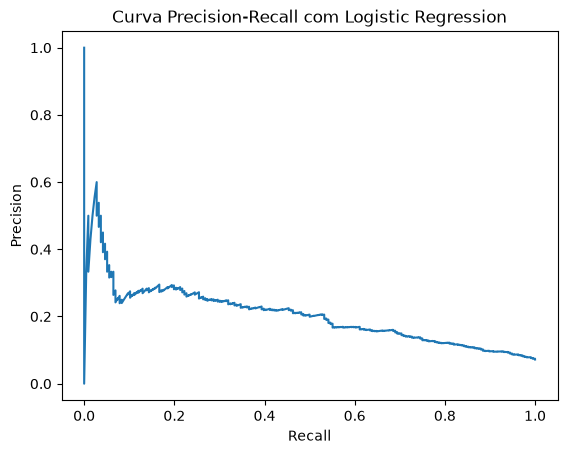

In [32]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    prob_suspeito
)
plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall com Logistic Regression')

plt.show()